<a href="https://colab.research.google.com/github/Suden-Cardiac-Arrest-FYP/ECG-image-classification/blob/main/ECG_VGG16_Train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫀 ECG Classification — VGG16 Professional Training + Flask Export
### Kaggle `ecg-analysis` dataset · Nested folder structure · Exports 3 files for Flask app

**Output files (Step 14 downloads them automatically):**
```
model/ecg_vgg16_model.keras   ← trained model
model/class_names.json         ← ordered class labels
model/model_meta.json          ← backbone + image size (used by Flask preprocessing)
```


## ⚡ Step 1 — GPU Check & Installs

In [1]:
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout if r.returncode == 0 else "⚠️  No GPU — go to Runtime > Change runtime type > T4 GPU")
import tensorflow as tf
print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))


Sun Mar 22 20:14:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q kaggle
print("✅ Packages ready")


✅ Packages ready


## 📦 Step 2 — Imports

In [3]:
import os, json, random, warnings, time, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
print("✅ Imports done")


✅ Imports done


## 🔧 Step 3 — Seed & Config

In [4]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── VGG16 native resolution ────────────────────────────────────────────────
IMG_SIZE        = (224, 224)    # VGG16's native size — DO NOT change to 100x100
IMG_SHAPE       = (*IMG_SIZE, 3)
BATCH_SIZE      = 32
EPOCHS_FROZEN   = 15            # Phase 1: head only, base frozen
EPOCHS_FINETUNE = 15            # Phase 2: fine-tune last 4 conv blocks
BASE_LR         = 1e-4
FINETUNE_LR     = 1e-5
NUM_CLASSES     = 4
BACKBONE        = "VGG16"

OUTPUT_DIR = "/content/flask_export"
MODEL_SAVE = f"{OUTPUT_DIR}/ecg_vgg16_model.keras"
CLASS_F    = f"{OUTPUT_DIR}/class_names.json"
META_F     = f"{OUTPUT_DIR}/model_meta.json"
CKPT_DIR   = "/content/checkpoints"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,   exist_ok=True)

print(f"✅ Config ready")
print(f"   Backbone   : {BACKBONE}")
print(f"   Image size : {IMG_SIZE}  (VGG16 native — critical for accuracy)")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   Export dir : {OUTPUT_DIR}")


✅ Config ready
   Backbone   : VGG16
   Image size : (224, 224)  (VGG16 native — critical for accuracy)
   Batch size : 32
   Export dir : /content/flask_export


## 📥 Step 4 — Download Dataset from Kaggle
> Upload your `kaggle.json` API key first, or mount Drive if you already have the data.

In [5]:
# Install dependency if needed
!pip install -q gdown

import os
import gdown
import zipfile

# Google Drive file ID
FILE_ID = "1OEk14Klk5WpMFNaNcUTHC-nSCnRRZZJu"

ZIP_PATH = "/content/ecg_data.zip"
EXTRACT_PATH = "/content/extracted_data"

# Download and extract dataset
if not os.path.exists(EXTRACT_PATH):
    print("⬇️ Downloading dataset from Google Drive...")

    gdown.download(
        f"https://drive.google.com/uc?id={FILE_ID}",
        ZIP_PATH,
        quiet=False
    )

    print("📦 Extracting dataset...")
    os.makedirs(EXTRACT_PATH, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_PATH)

    os.remove(ZIP_PATH)

    print("✅ Dataset ready at:", EXTRACT_PATH)

else:
    print("✅ Dataset already extracted — skipping download")


# Example dataset path (adjust if needed)
DATA_PATH = os.path.join(EXTRACT_PATH, "ECG_DATA/train")

print("\nDATA_PATH =", DATA_PATH)
print("Exists    :", os.path.isdir(DATA_PATH))

if os.path.isdir(DATA_PATH):
    print("Contents  :", os.listdir(DATA_PATH))

⬇️ Downloading dataset from Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1OEk14Klk5WpMFNaNcUTHC-nSCnRRZZJu
From (redirected): https://drive.google.com/uc?id=1OEk14Klk5WpMFNaNcUTHC-nSCnRRZZJu&confirm=t&uuid=54484ad6-2a08-416a-b94f-e88758858574
To: /content/ecg_data.zip
100%|██████████| 867M/867M [00:11<00:00, 73.7MB/s]


📦 Extracting dataset...
✅ Dataset ready at: /content/extracted_data

DATA_PATH = /content/extracted_data/ECG_DATA/train
Exists    : True
Contents  : ['Normal Person ECG Images (284x12=3408)', 'ECG Images of Myocardial Infarction Patients (240x12=2880)', 'ECG Images of Patient that have History of MI (172x12=2064)', 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)']


## 🗂️ Step 5 — Load Data (Handles Nested Folder Structure)

In [6]:
# ── Nested folder loader (mirrors the Kaggle notebook exactly) ──────────────
# Dataset structure:
#   train/
#     CategoryA/          ← ignored as label
#       ClassX/           ← label = "ClassX"
#         img1.png
#     ClassY/             ← label = "ClassY" (flat case)
#       img2.png

assert os.path.isdir(DATA_PATH), f"❌ Path not found: {DATA_PATH}"

images, labels = [], []

for category_folder in os.listdir(DATA_PATH):
    category_path = os.path.join(DATA_PATH, category_folder)
    if not os.path.isdir(category_path):
        continue

    subitems = os.listdir(category_path)
    has_subfolders = any(
        os.path.isdir(os.path.join(category_path, item)) for item in subitems
    )

    if has_subfolders:
        # Nested: label = subfolder name
        for subfolder in subitems:
            subfolder_path = os.path.join(category_path, subfolder)
            if not os.path.isdir(subfolder_path):
                continue
            for fname in os.listdir(subfolder_path):
                if fname.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tiff')):
                    images.append(os.path.join(subfolder_path, fname))
                    labels.append(subfolder)
    else:
        # Flat: label = category folder name
        for fname in subitems:
            if fname.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tiff')):
                images.append(os.path.join(category_path, fname))
                labels.append(category_folder)

data        = pd.DataFrame({'image': images, 'label': labels})
CLASS_NAMES = sorted(data['label'].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)

print(f"✅ Total images : {len(data)}")
print(f"   Classes found: {CLASS_NAMES}")
print("\nLabel distribution:")
print(data['label'].value_counts())


✅ Total images : 3023
   Classes found: ['ECG Images of Myocardial Infarction Patients (240x12=2880)', 'ECG Images of Patient that have History of MI (172x12=2064)', 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)', 'Normal Person ECG Images (284x12=3408)']

Label distribution:
label
ECG Images of Myocardial Infarction Patients (240x12=2880)          956
Normal Person ECG Images (284x12=3408)                              852
ECG Images of Patient that have abnormal heartbeat (233x12=2796)    699
ECG Images of Patient that have History of MI (172x12=2064)         516
Name: count, dtype: int64


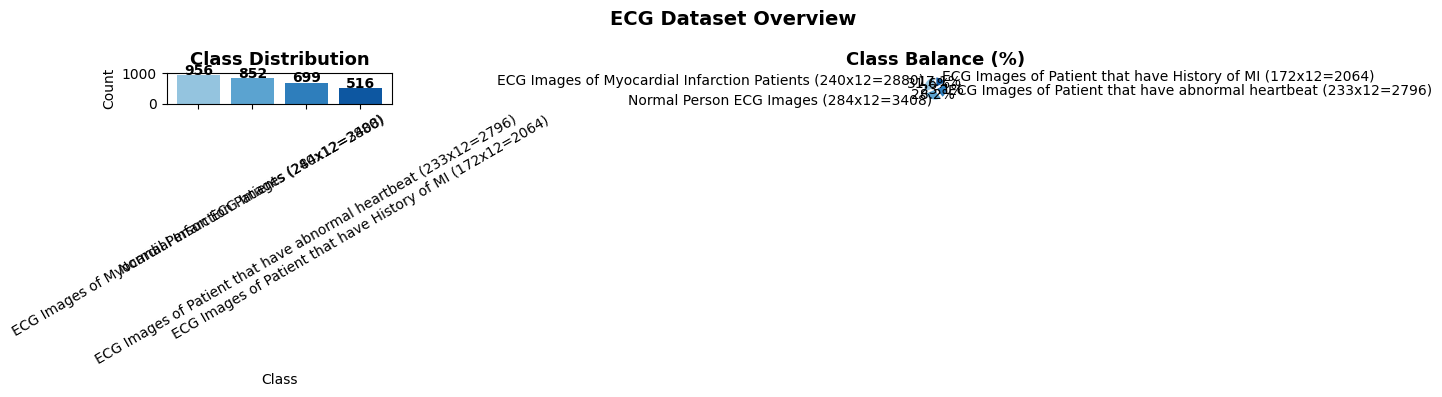

Imbalance ratio: 1.85x ⚠️ applying class weights


In [7]:
# EDA charts
counts = data['label'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(counts.index, counts.values,
            color=plt.cm.Blues(np.linspace(0.4, 0.85, len(counts))))
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i,v in enumerate(counts.values):
    axes[0].text(i, v+2, str(v), ha='center', fontweight='bold', fontsize=10)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=plt.cm.Blues(np.linspace(0.4, 0.85, len(counts))),
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Class Balance (%)', fontsize=13, fontweight='bold')
plt.suptitle('ECG Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

ratio = counts.max() / counts.min()
print(f"Imbalance ratio: {ratio:.2f}x {'⚠️ applying class weights' if ratio>1.5 else '✅ balanced'}")


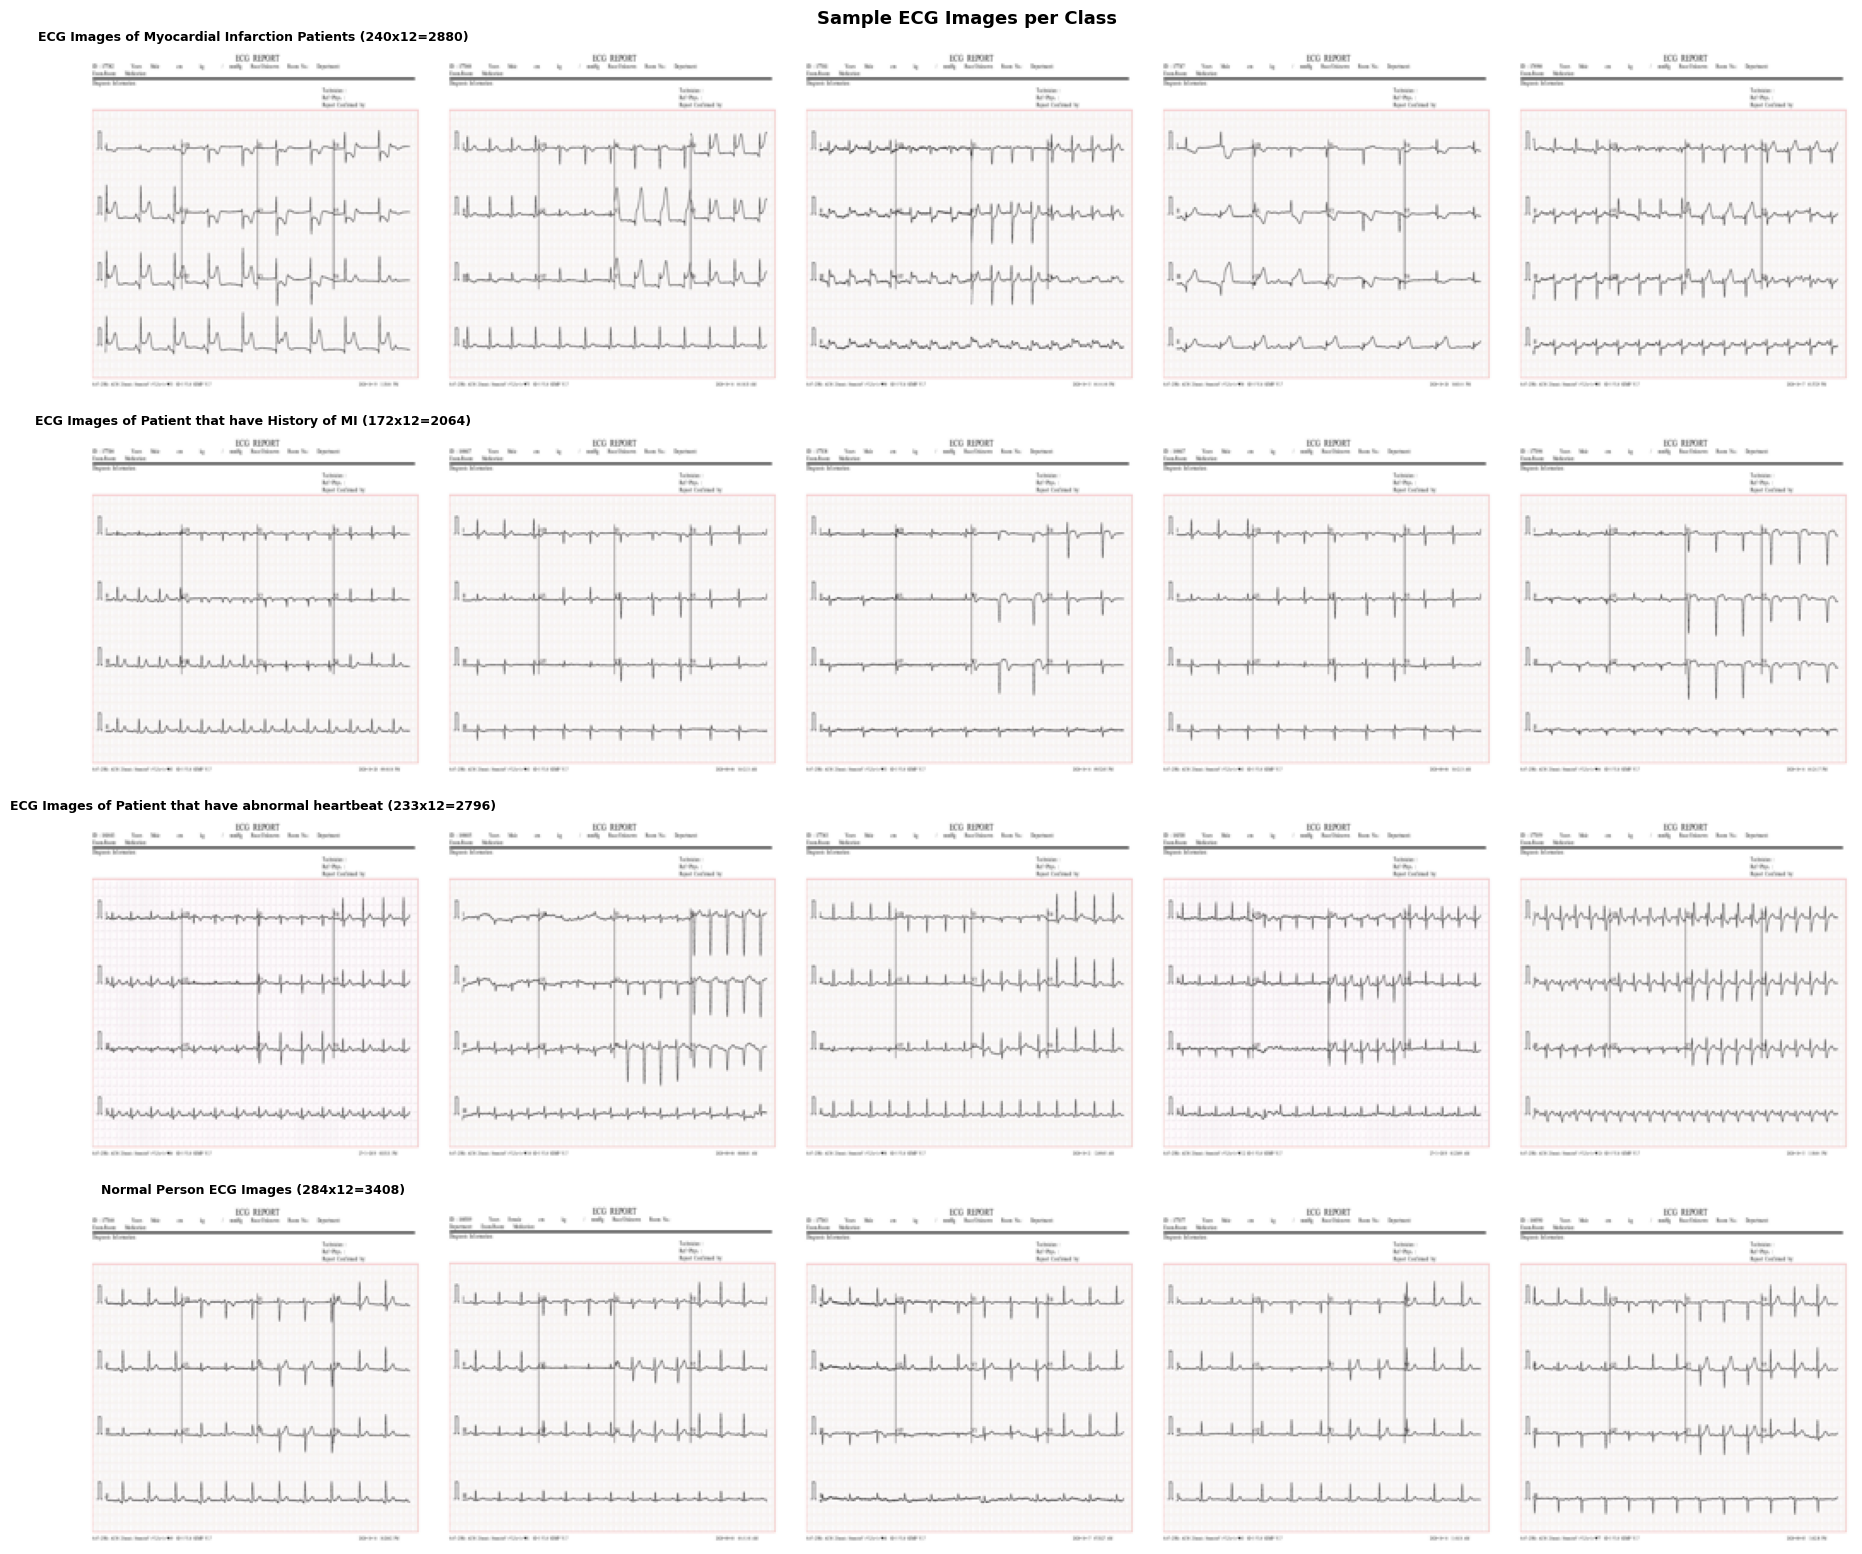

In [8]:
# Sample images per class
fig, axes = plt.subplots(len(CLASS_NAMES), 5, figsize=(18, 4*len(CLASS_NAMES)))
for ri, cname in enumerate(CLASS_NAMES):
    samples = data[data['label']==cname]['image'].values[:5]
    row = axes[ri] if len(CLASS_NAMES) > 1 else axes
    for ci, path in enumerate(samples):
        img = Image.open(path).convert('RGB').resize((200,200))
        row[ci].imshow(img)
        row[ci].set_title(cname if ci==0 else '', fontsize=9, fontweight='bold')
        row[ci].axis('off')
plt.suptitle('Sample ECG Images per Class', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## ✂️ Step 6 — Train / Val / Test Split & Class Weights

In [9]:
train_df, temp_df = train_test_split(
    data, train_size=0.80, shuffle=True, random_state=SEED, stratify=data['label'])
valid_df, test_df = train_test_split(
    temp_df, train_size=0.50, shuffle=True, random_state=SEED, stratify=temp_df['label'])

print(f"Train: {len(train_df)} | Val: {len(valid_df)} | Test: {len(test_df)}")

weights      = compute_class_weight('balanced',
    classes=np.array(CLASS_NAMES), y=train_df['label'].values)
CLASS_WEIGHT = {i: w for i, w in enumerate(weights)}
print("\nClass weights:", {CLASS_NAMES[i]:round(w,3) for i,w in CLASS_WEIGHT.items()})


Train: 2418 | Val: 302 | Test: 303

Class weights: {'ECG Images of Myocardial Infarction Patients (240x12=2880)': np.float64(0.79), 'ECG Images of Patient that have History of MI (172x12=2064)': np.float64(1.464), 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)': np.float64(1.081), 'Normal Person ECG Images (284x12=3408)': np.float64(0.888)}


## 🎨 Step 7 — ECG-Safe Augmentation & Generators
> **Critical**: using `vgg16_preprocess` (BGR + ImageNet mean subtraction), not raw /255.

In [10]:
# ECG rules:
#  ✅ Mild shift, scale, rotation ≤ 8°
#  ✅ Brightness/contrast variation (simulates scan quality)
#  ❌ NO horizontal_flip  — flipping reverses P/T-wave polarity
#  ❌ NO vertical_flip    — flipping inverts waveform amplitude
#  ❌ NO large rotation   — ECG timeline must read left→right

def train_preprocess(image):
    """ECG-safe augmentation + VGG16 preprocessing."""
    img_u8 = np.clip(image, 0, 255).astype(np.uint8)

    # Random brightness/contrast (safe for ECG)
    if random.random() < 0.5:
        factor = random.uniform(0.85, 1.15)
        img_u8 = np.clip(img_u8.astype(np.float32) * factor, 0, 255).astype(np.uint8)

    # Tiny shift (≤5%)
    if random.random() < 0.4:
        h, w = img_u8.shape[:2]
        dx = int(w * random.uniform(-0.05, 0.05))
        dy = int(h * random.uniform(-0.05, 0.05))
        M  = np.float32([[1,0,dx],[0,1,dy]])
        img_u8 = cv2.warpAffine(img_u8, M, (w,h), borderMode=cv2.BORDER_REPLICATE)

    # Very small rotation (≤8°)
    if random.random() < 0.4:
        h, w = img_u8.shape[:2]
        angle = random.uniform(-8, 8)
        M     = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        img_u8 = cv2.warpAffine(img_u8, M, (w,h), borderMode=cv2.BORDER_REPLICATE)

    # VGG16-specific preprocessing (BGR + ImageNet mean subtraction)
    return vgg16_preprocess(img_u8.astype(np.float32))

def eval_preprocess(image):
    """VGG16 preprocessing only — no augmentation."""
    return vgg16_preprocess(image.astype(np.float32))

tr_datagen   = ImageDataGenerator(preprocessing_function=train_preprocess)
eval_datagen = ImageDataGenerator(preprocessing_function=eval_preprocess)

def make_gen(datagen, df, shuffle):
    return datagen.flow_from_dataframe(
        df, x_col='image', y_col='label',
        target_size=IMG_SIZE,      # 224x224 — VGG16 native
        class_mode='categorical',
        color_mode='rgb',
        shuffle=shuffle,
        batch_size=BATCH_SIZE,
        seed=SEED)

train_gen = make_gen(tr_datagen,   train_df, shuffle=True)
valid_gen = make_gen(eval_datagen, valid_df, shuffle=False)
test_gen  = make_gen(eval_datagen, test_df,  shuffle=False)

CLASS_NAMES_ORDERED = [k for k,v in sorted(train_gen.class_indices.items(), key=lambda x:x[1])]
print(f"✅ Generators ready")
print(f"   Class order (matches model output): {CLASS_NAMES_ORDERED}")


Found 2418 validated image filenames belonging to 4 classes.
Found 302 validated image filenames belonging to 4 classes.
Found 303 validated image filenames belonging to 4 classes.
✅ Generators ready
   Class order (matches model output): ['ECG Images of Myocardial Infarction Patients (240x12=2880)', 'ECG Images of Patient that have History of MI (172x12=2064)', 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)', 'Normal Person ECG Images (284x12=3408)']


## 🧠 Step 8 — Build Professional VGG16 Model

In [11]:
def build_vgg16_model(num_classes, lr=BASE_LR):
    """
    Two-phase VGG16 transfer learning model.
    Phase 1: freeze all base layers, train head only.
    Phase 2: unfreeze last 4 conv blocks for fine-tuning.
    """
    base = VGG16(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)
    base.trainable = False   # frozen for Phase 1

    inputs = Input(shape=IMG_SHAPE)
    x = base(inputs, training=False)

    # Classification head
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)

    x = Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = Dropout(0.5)(x)

    x = Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inputs, outputs, name="ECG_VGG16")
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )
    return model

model = build_vgg16_model(NUM_CLASSES)
model.summary()
print(f"\nTotal params: {model.count_params():,}")
print(f"VGG16 layers: {len(model.layers[1].layers)}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "ECG_VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,114,820 (57.66 MB)

 Trainable params: 397,572 (1.52 MB)

 Non-trainable params: 14,717,248 (56.14 MB)


Total params: 15,114,820
VGG16 layers: 19


## 🚀 Step 9 — Phase 1: Train Head (VGG16 Frozen)

In [12]:
def get_callbacks(phase):
    ckpt = os.path.join(CKPT_DIR, f"vgg16_p{phase}_best.keras")
    return [
        ModelCheckpoint(ckpt, monitor='val_accuracy', save_best_only=True,
                        verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=7,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=4, min_lr=1e-9, verbose=1),
        CSVLogger(f"/content/vgg16_p{phase}_log.csv"),
    ], ckpt

cbs_p1, ckpt_p1 = get_callbacks(phase=1)

print("="*60)
print(f"PHASE 1 — VGG16 base: FROZEN | LR: {BASE_LR}")
print("="*60)

history_p1 = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS_FROZEN,
    callbacks=cbs_p1,
    class_weight=CLASS_WEIGHT,
    verbose=1
)

best_p1 = max(history_p1.history['val_accuracy'])
print(f"\n✅ Phase 1 done | Best val accuracy: {best_p1:.4f}")

PHASE 1 — VGG16 base: FROZEN | LR: 0.0001
Epoch 1/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 957ms/step - accuracy: 0.3430 - auc: 0.6043 - loss: 1.6664 - precision: 0.3633 - recall: 0.1721
Epoch 1: val_accuracy improved from None to 0.30795, saving model to /content/checkpoints/vgg16_p1_best.keras

Epoch 1: finished saving model to /content/checkpoints/vgg16_p1_best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.3548 - auc: 0.6247 - loss: 1.6124 - precision: 0.3972 - recall: 0.1911 - val_accuracy: 0.3079 - val_auc: 0.6606 - val_loss: 1.4565 - val_precision: 0.4362 - val_recall: 0.2152 - learning_rate: 1.0000e-04
Epoch 2/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.4443 - auc: 0.7108 - loss: 1.4248 - precision: 0.5140 - recall: 0.2772
Epoch 2: val_accuracy improved from 0.30795 to 0.58278, saving model to /content/checkpoints/vgg16_p1_best.keras

Epoch 2: finished saving model to /content/checkpoints/vgg16_p1_best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 69s 910ms/step - accurac

## 🔓 Step 10 — Phase 2: Fine-Tune Last Conv Blocks

In [13]:
# VGG16 block layout (19 weight layers):
#   block1_conv1/2  | block2_conv1/2
#   block3_conv1/2/3 | block4_conv1/2/3 | block5_conv1/2/3  ← unfreeze last N
#
# Unfreeze last 4 layers = block5_conv2 + block5_conv3 (good balance)
# Unfreeze more if you have lots of data.

N_UNFREEZE = 4   # last N layers of VGG16 base to unfreeze

vgg_base = model.layers[1]
vgg_base.trainable = True
for layer in vgg_base.layers[:-N_UNFREEZE]:
    layer.trainable = False

trainable_layers = [l.name for l in vgg_base.layers if l.trainable]
print(f"Unfrozen VGG16 layers ({len(trainable_layers)}): {trainable_layers}")

model.compile(
    optimizer=Adam(learning_rate=FINETUNE_LR),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)
print(f"\n✅ Fine-tune LR: {FINETUNE_LR}")


Unfrozen VGG16 layers (4): ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']

✅ Fine-tune LR: 1e-05


In [14]:
cbs_p2, ckpt_p2 = get_callbacks(phase=2)

print("="*60)
print(f"PHASE 2 — VGG16 top {N_UNFREEZE} layers UNFROZEN | LR: {FINETUNE_LR}")
print("="*60)

history_p2 = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS_FINETUNE,
    callbacks=cbs_p2,
    class_weight=CLASS_WEIGHT,
    verbose=1
)

best_p2 = max(history_p2.history['val_accuracy'])
print(f"\n✅ Phase 2 done | Best val accuracy: {best_p2:.4f}")


PHASE 2 — VGG16 top 4 layers UNFROZEN | LR: 1e-05
Epoch 1/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 920ms/step - accuracy: 0.7134 - auc: 0.9179 - loss: 0.9565 - precision: 0.7888 - recall: 0.6371
Epoch 1: val_accuracy improved from None to 0.86093, saving model to /content/checkpoints/vgg16_p2_best.keras

Epoch 1: finished saving model to /content/checkpoints/vgg16_p2_best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.7291 - auc: 0.9209 - loss: 0.9507 - precision: 0.7942 - recall: 0.6447 - val_accuracy: 0.8609 - val_auc: 0.9819 - val_loss: 0.7031 - val_precision: 0.9051 - val_recall: 0.8212 - learning_rate: 1.0000e-05
Epoch 2/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 813ms/step - accuracy: 0.7524 - auc: 0.9359 - loss: 0.9170 - precision: 0.8195 - recall: 0.6872
Epoch 2: val_accuracy improved from 0.86093 to 0.89073, saving model to /content/checkpoints/vgg16_p2_best.keras

Epoch 2: finished saving model to /content/checkpoints/vgg16_p2_best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 70s 913ms/step - 

## 📊 Step 11 — Training History

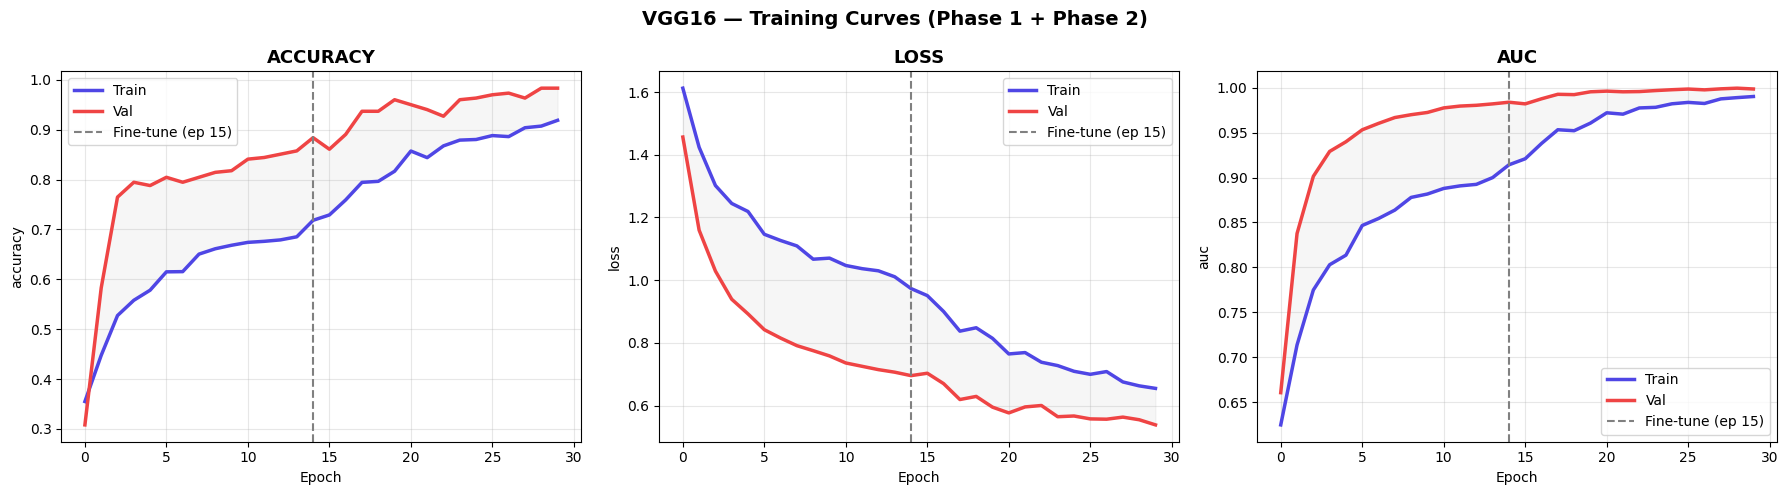

In [15]:
p1 = len(history_p1.history['accuracy'])
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, ['accuracy','loss','auc']):
    tr = history_p1.history.get(m,[]) + history_p2.history.get(m,[])
    va = history_p1.history.get(f'val_{m}',[]) + history_p2.history.get(f'val_{m}',[])
    if not tr: continue
    ax.plot(tr, label='Train', linewidth=2.5, color='#4f46e5')
    ax.plot(va, label='Val',   linewidth=2.5, color='#ef4444')
    ax.axvline(p1-1, color='gray', linestyle='--', linewidth=1.5, label=f'Fine-tune (ep {p1})')
    ax.fill_between(range(len(tr)), tr, va, alpha=0.07, color='gray')
    ax.set_title(m.upper(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(m); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('VGG16 — Training Curves (Phase 1 + Phase 2)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 🏆 Step 12 — Evaluate on Test Set

In [16]:
# Load best checkpoint
print(f"Loading best model: {ckpt_p2}")
best_model = tf.keras.models.load_model(ckpt_p2, compile=False)

test_gen.reset()
y_true, y_proba = [], []
for i in range(len(test_gen)):
    X, y = test_gen[i]
    y_true.extend(np.argmax(y, axis=1))
    y_proba.extend(best_model.predict(X, verbose=0))

y_true  = np.array(y_true)
y_proba = np.array(y_proba)
y_pred  = np.argmax(y_proba, axis=1)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
y_bin   = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
auc_sc  = roc_auc_score(y_bin, y_proba, average='macro', multi_class='ovr')

print("\n" + "="*55)
print(f"TEST SET RESULTS — VGG16")
print("="*55)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES_ORDERED, digits=4))
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc_sc:.4f}")


Loading best model: /content/checkpoints/vgg16_p2_best.keras

TEST SET RESULTS — VGG16
                                                                  precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients (240x12=2880)     1.0000    1.0000    1.0000        96
     ECG Images of Patient that have History of MI (172x12=2064)     1.0000    0.9216    0.9592        51
ECG Images of Patient that have abnormal heartbeat (233x12=2796)     0.8974    1.0000    0.9459        70
                          Normal Person ECG Images (284x12=3408)     1.0000    0.9535    0.9762        86

                                                        accuracy                         0.9736       303
                                                       macro avg     0.9744    0.9688    0.9703       303
                                                    weighted avg     0.9763    0.9736    0.9739       303

  Accuracy  : 0.9736
  Precision : 0.9763
  Recall    : 0.9736

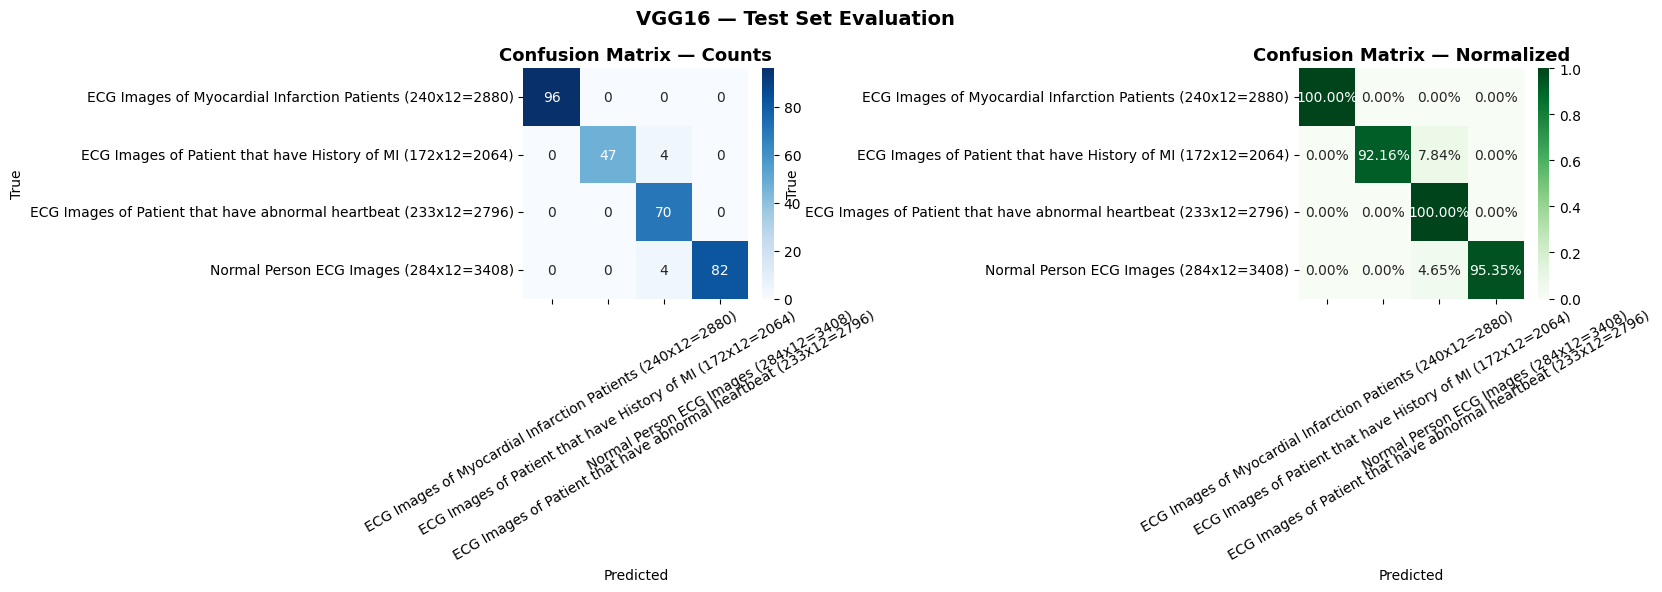

In [17]:
# Confusion matrices
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES_ORDERED, yticklabels=CLASS_NAMES_ORDERED, ax=axes[0])
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=30)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=CLASS_NAMES_ORDERED, yticklabels=CLASS_NAMES_ORDERED, ax=axes[1])
axes[1].set_title('Confusion Matrix — Normalized', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=30)
plt.suptitle('VGG16 — Test Set Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


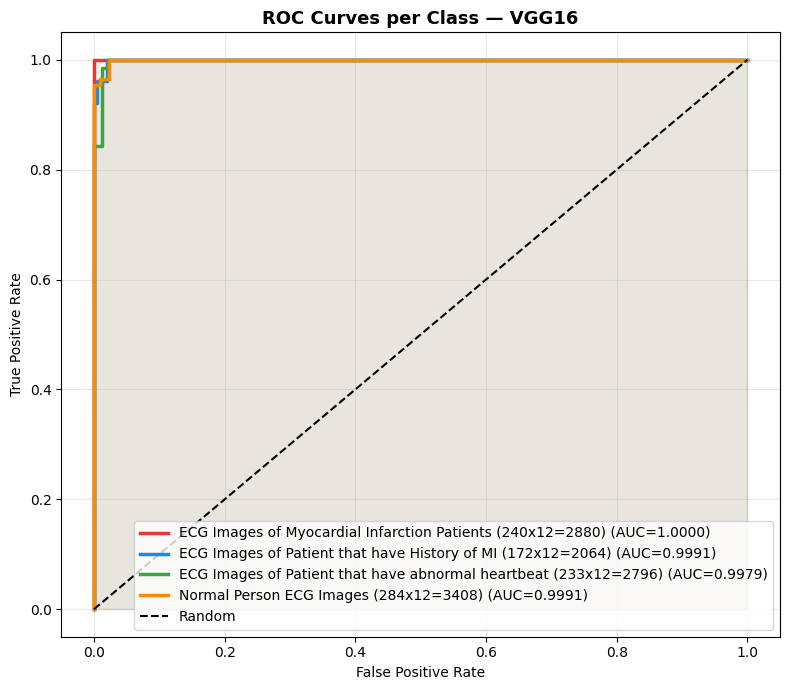

In [18]:
# ROC curves
colors = ['#E53935','#1E88E5','#43A047','#FB8C00']
fig, ax = plt.subplots(figsize=(8, 7))
for i, (cname, col) in enumerate(zip(CLASS_NAMES_ORDERED, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_proba[:,i])
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2.5, color=col, label=f'{cname} (AUC={auc_val:.4f})')
    ax.fill_between(fpr, tpr, alpha=0.05, color=col)
ax.plot([0,1],[0,1],'k--', linewidth=1.5, label='Random')
ax.set_title('ROC Curves per Class — VGG16', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 💾 Step 13 — Export 3 Files for Flask App

In [19]:
print("="*60)
print("  EXPORTING FILES FOR FLASK APP")
print("="*60)

# 1. Model
print(f"\n[1/3] Saving model → {MODEL_SAVE}")
best_model.save(MODEL_SAVE)
size_mb = os.path.getsize(MODEL_SAVE)/(1024*1024)
print(f"      ✅ {size_mb:.1f} MB")

# 2. Class names — ORDER MATTERS, must match model output indices
print(f"\n[2/3] Saving class names → {CLASS_F}")
with open(CLASS_F, 'w') as f:
    json.dump(CLASS_NAMES_ORDERED, f, indent=2)
print(f"      ✅ {CLASS_NAMES_ORDERED}")

# 3. Model meta — Flask reads this to pick correct preprocessing fn
print(f"\n[3/3] Saving model meta → {META_F}")
meta = {
    "backbone":      "VGG16",
    "img_size":      list(IMG_SIZE),      # [224, 224]
    "num_classes":   NUM_CLASSES,
    "class_names":   CLASS_NAMES_ORDERED,
    "test_accuracy": round(float(acc),  4),
    "test_auc":      round(float(auc_sc),4),
    "test_f1":       round(float(f1),   4),
    "test_recall":   round(float(rec),  4),
}
with open(META_F, 'w') as f:
    json.dump(meta, f, indent=2)
print(f"      ✅")
print(json.dumps(meta, indent=4))

print("\n" + "="*60)
print(f"  ✅ ALL 3 FILES READY IN: {OUTPUT_DIR}")
print("="*60)


  EXPORTING FILES FOR FLASK APP

[1/3] Saving model → /content/flask_export/ecg_vgg16_model.keras
      ✅ 57.8 MB

[2/3] Saving class names → /content/flask_export/class_names.json
      ✅ ['ECG Images of Myocardial Infarction Patients (240x12=2880)', 'ECG Images of Patient that have History of MI (172x12=2064)', 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)', 'Normal Person ECG Images (284x12=3408)']

[3/3] Saving model meta → /content/flask_export/model_meta.json
      ✅
{
    "backbone": "VGG16",
    "img_size": [
        224,
        224
    ],
    "num_classes": 4,
    "class_names": [
        "ECG Images of Myocardial Infarction Patients (240x12=2880)",
        "ECG Images of Patient that have History of MI (172x12=2064)",
        "ECG Images of Patient that have abnormal heartbeat (233x12=2796)",
        "Normal Person ECG Images (284x12=3408)"
    ],
    "test_accuracy": 0.9736,
    "test_auc": 0.999,
    "test_f1": 0.9739,
    "test_recall": 0.9736
}

  ✅ A

## ✔️ Step 14 — Verify & Download

In [20]:
# Verify files
print("Exported files:")
for fpath in [MODEL_SAVE, CLASS_F, META_F]:
    sz = os.path.getsize(fpath)/1024
    unit = "KB" if sz < 1024 else "MB"
    sz   = sz if sz < 1024 else sz/1024
    print(f"  ✅  {Path(fpath).name:<35} {sz:>7.1f} {unit}")

# Sanity check: reload and predict
print("\nRunning reload + forward pass check...")
loaded = tf.keras.models.load_model(MODEL_SAVE, compile=False)
with open(CLASS_F)  as f: lc = json.load(f)
with open(META_F)   as f: lm = json.load(f)

dummy_img = np.random.rand(1, 224, 224, 3).astype(np.float32)
dummy_img = (dummy_img * 255).astype(np.float32)
# Apply VGG16 preprocessing (as Flask will do)
from tensorflow.keras.applications.vgg16 import preprocess_input as _pre
dummy_proc = _pre(dummy_img)
out = loaded.predict(dummy_proc, verbose=0)
assert out.shape == (1, NUM_CLASSES), f"Bad shape: {out.shape}"
assert abs(out.sum()-1.0) < 1e-3,    f"Probs don't sum to 1: {out.sum()}"
print(f"  ✅ Shape: {out.shape} | Sum: {out.sum():.4f} | Classes: {lc}")


Exported files:
  ✅  ecg_vgg16_model.keras                  57.8 MB
  ✅  class_names.json                        0.2 KB
  ✅  model_meta.json                         0.4 KB

Running reload + forward pass check...
  ✅ Shape: (1, 4) | Sum: 1.0000 | Classes: ['ECG Images of Myocardial Infarction Patients (240x12=2880)', 'ECG Images of Patient that have History of MI (172x12=2064)', 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)', 'Normal Person ECG Images (284x12=3408)']


In [21]:
# ── Download all 3 files ──────────────────────────────────────────────────────
from google.colab import files

print("⬇️  Downloading files...\n")
for fpath, label in [
    (MODEL_SAVE, "ecg_vgg16_model.keras"),
    (CLASS_F,    "class_names.json"),
    (META_F,     "model_meta.json"),
]:
    print(f"  Downloading {label} …")
    files.download(fpath)

print("\n✅ All 3 files downloaded!")
print("\nNext steps:")
print("  1. Create a  model/  folder in your Flask app directory")
print("  2. Move all 3 files into it")
print("  3. Run:  pip install -r requirements.txt")
print("  4. Run:  python app.py")
print("  5. Open: http://localhost:5001")


⬇️  Downloading files...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All 3 files downloaded!

Next steps:
  1. Create a  model/  folder in your Flask app directory
  2. Move all 3 files into it
  3. Run:  pip install -r requirements.txt
  4. Run:  python app.py
  5. Open: http://localhost:5001


## ☁️ Step 15 (Optional) — Save to Google Drive

In [22]:
# from google.colab import drive
# drive.mount('/content/drive')
# import shutil
# DRIVE_OUT = "/content/drive/MyDrive/ECG_VGG16_Flask_Export"
# os.makedirs(DRIVE_OUT, exist_ok=True)
# for fpath in [MODEL_SAVE, CLASS_F, META_F]:
#     shutil.copy(fpath, os.path.join(DRIVE_OUT, Path(fpath).name))
#     print(f"✅ Saved to Drive: {Path(fpath).name}")
print("Uncomment the above to save to Google Drive as backup.")


Uncomment the above to save to Google Drive as backup.


## 🩺 Step 16 — Inference Demo (Flask-Identical Pipeline)

In [23]:
def flask_predict(image_path: str) -> dict:
    """
    Mirrors EXACTLY what model_utils.py does in the Flask app.
    Use this to validate your model before deploying.
    """
    from tensorflow.keras.applications.vgg16 import preprocess_input as _vgg_pre

    img = Image.open(image_path).convert('RGB').resize((224, 224), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32)
    arr = _vgg_pre(arr)                  # VGG16: BGR + ImageNet mean subtraction
    arr = np.expand_dims(arr, axis=0)   # (1, 224, 224, 3)

    probs    = loaded.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    return {
        "predicted_class": lc[pred_idx],
        "confidence":      float(probs[pred_idx]),
        "all_probabilities": {c: float(p) for c, p in zip(lc, probs)},
    }

# Run on one sample per class
print("\n" + "="*55)
print("  DEMO PREDICTIONS (Flask-identical pipeline)")
print("="*55)
for cname in CLASS_NAMES_ORDERED:
    sample = data[data['label']==cname]['image'].iloc[0]
    r      = flask_predict(sample)
    match  = "✅" if r["predicted_class"] == cname else "❌"
    print(f"  {match}  True: {cname:<20}  Pred: {r['predicted_class']:<20}  Conf: {r['confidence']:.2%}")



  DEMO PREDICTIONS (Flask-identical pipeline)
  ❌  True: ECG Images of Myocardial Infarction Patients (240x12=2880)  Pred: ECG Images of Patient that have History of MI (172x12=2064)  Conf: 76.75%
  ✅  True: ECG Images of Patient that have History of MI (172x12=2064)  Pred: ECG Images of Patient that have History of MI (172x12=2064)  Conf: 51.64%
  ❌  True: ECG Images of Patient that have abnormal heartbeat (233x12=2796)  Pred: ECG Images of Myocardial Infarction Patients (240x12=2880)  Conf: 42.76%
  ❌  True: Normal Person ECG Images (284x12=3408)  Pred: ECG Images of Patient that have History of MI (172x12=2064)  Conf: 39.18%
